In [54]:
%load_ext autoreload
%autoreload 2

from IPython.display import Math, Latex

import pandas as pd, cvxpy as cp, numpy as np, matplotlib as mpl  # type: ignore
import matplotlib.pyplot as plt  # type: ignore

from matplotlib.ticker import FuncFormatter, MultipleLocator  # type: ignore
from matplotlib.patches import FancyArrowPatch, Polygon  # type: ignore
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from scipy.integrate import quad  # type: ignore
from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d

import importlib, itertools, csv, concurrent.futures
import os, math, sys, json, pickle, shutil, time, functools

from typing import Dict, List, Any, Optional, Literal
from tqdm.notebook import tqdm
import networkx as nx

from Utils import Notebook, tex, gph, sgn, nm, ds
from Simulator import *
# from SimulatorOld import *
from optimization import DisturbedSaturatedPETC as DSPETC
import TrafficModels as tm

cfg = {
    'style': {'color': 'black'},
    'axis': {
        'title_pad': 10,
        'x_label_fontsize': 16,
        'y_label_fontsize': 16,
        'tick_fontsize': 16,
    },
    'legend': {'fontsize': 16}
}

colors_list = plt.get_cmap('tab20').colors
Notebook.setup()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


LaTeX has been enabled for text rendering.


### Definição da Planta

In [55]:
experiment_filename = 'exp-03'

with open(f"experiment-datas/{experiment_filename}.json", encoding='utf-8') as f:
  exp_data = json.load(f)

plant = ds.StateSpace(data=exp_data["plant"], name='plant')
latex_expr = plant.get_latex_equations()
print("Equações que regem a dinâmica da planta:")
tex.display_latex(latex_expr)

Equações que regem a dinâmica da planta:


<IPython.core.display.Latex object>

### Projeto do Controlador e do ETM

In [56]:
import Simulator
import matplotlib.pyplot as plt

# Parâmetros
EXPERIMENT_FILE = f"experiment-datas/{experiment_filename}.json"

In [57]:
def solve_problem_sigma(
    h: float,
    υ: float,
    eps: float = 1e-6,
    σ: float = 0.0,
    εtr: float = 0.0,
    K: np.array = None
):
  n_x = plant.nx
  n_u = plant.nu

  Onx = np.zeros((n_x, n_x))

  matrices = plant.evaluate_matrices(None, None, None)
  A = matrices['A']
  B = matrices['B']

  e = nm.get_e(5 * [n_x])

  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i], name=f"e{i}")

  constraints = []

  Ptil = cp.Variable((n_x, n_x), PSD=True)
  Mtil = cp.Variable((2 * n_x, 2 * n_x), PSD=True)
  Q1til = cp.Variable((n_x, n_x), symmetric=True)
  Q2til = cp.Variable((n_x, n_x))
  Q3til = cp.Variable((n_x, n_x))
  S1til = cp.Variable((n_x, n_x), symmetric=True)
  S2til = cp.Variable((n_x, n_x))
  S3til = cp.Variable((n_x, n_x))

  if K is None:
    Ktil = cp.Variable((n_u, n_x))
  else:
    Ktil = cp.Parameter((n_u, n_x), value=K)

  Rtil = cp.Variable((n_x, n_x), PSD=True)
  Ξtil = cp.Variable((n_x, n_x), PSD=True)
  # Ξtil = cp.Parameter((n_x, n_x), value=np.eye(n_x))

  if σ == 0.0:
    Ψtil = cp.Variable((n_x, n_x), PSD=True)
    # Ψtil = cp.Parameter((n_x, n_x), value=np.eye(n_x))

  X = cp.Variable((n_x, n_x))
  Ytil = cp.Variable((2 * n_x, e[1].shape[1]))

  Rcal = cp.bmat([[Rtil, Onx],
                  [Onx, 3. * Rtil]])

  Fscr = e[1].T + υ * e[2].T + υ * e[4].T

  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1] - e[2]],
                [e[1] + e[2] - 2. * e[3]]])

  def get_Θ(ω):
    if K is None:
      Bscr = A @ X @ e[1] + B @ Ktil @ e[2] + \
          B @ Ktil @ e[5] - X @ e[4]
    else:
      Bscr = A @ X @ e[1] + B @ Ktil @ X @ e[2] + \
          B @ Ktil @ X @ e[5] - X @ e[4]
    Θ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))
    Θ2 = nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))
    Θ3 = nm.He(e[1].T @ (Q1til @ e[3] + Q2til @ e[2] + Q3til @ e[5]))
    Θ4 = nm.He(e[4].T @ (S1til @ (e[1] - e[2]) + S2til @
               e[2] + S3til @ e[5])) + e[4].T @ Rtil @ e[4]
    return nm.He(e[1].T @ Ptil @ e[4] + Fscr @ Bscr - κ2.T @ Ytil) - e[5].T @ Ξtil @ e[5] - \
        Θ1 - ω * Θ2 - h * e[3].T @ Q1til @ e[3] + \
        (h - ω) * Θ3 + (h - 2.0 * ω) * κ1.T @ Mtil @ κ1 + \
        (h - ω) * Θ4 + σ * e[2].T @ Ξtil @ e[2]

  def get_Γ():
    Γ1_11 = get_Θ(0)
    Γ1 = Γ1_11

    if σ == 0.0:
      Γ1_12 = e[2].T @ X.T

      Γ1_21 = Γ1_12.T
      Γ1_22 = - Ψtil

      Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                    [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θ(h)
    Γ2_12 = Ytil.T

    Γ2_21 = Γ2_12.T
    Γ2_22 = - (1. / h) * Rcal

    Γ2 = cp.bmat([[Γ2_11, Γ2_12],
                  [Γ2_21, Γ2_22]])

    if σ == 0.0:
      Γ2_13 = e[2].T @ X.T
      Γ2_23 = np.zeros((2 * n_x, n_x))
      Γ2_31 = Γ2_13.T
      Γ2_32 = Γ2_23.T
      Γ2_33 = - Ψtil

      Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                    [Γ2_21, Γ2_22, Γ2_23],
                    [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  Γ1, Γ2 = get_Γ()
  constraints += [Γ1 << -eps * np.eye(Γ1.shape[0])]
  constraints += [Γ2 << -eps * np.eye(Γ2.shape[0])]

  constraints += [Ξtil >> eps * np.eye(n_x)]
  if σ == 0.0:
    constraints += [Ψtil >> eps * np.eye(n_x)]

  if σ == 0.0:
    if εtr == 0.0:
      obj = cp.Minimize(cp.trace(Ξtil + Ψtil))
    else:
      constraints += [cp.trace(Ξtil + Ψtil) <= εtr]
      obj = cp.Minimize(0.0)
  else:
    obj = cp.Minimize(0.0)
  prob = cp.Problem(obj, constraints)

  try:
    # Tenta resolver o problema de otimização
    prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

    # Verifica o status do solver após a execução
    if prob.status in ["infeasible", "unbounded"]:
      # O solver terminou, mas o problema é infactível ou ilimitado
      return None

    # Se chegou aqui, o solver obteve sucesso. Processa e retorna os resultados.
    Xinv = np.linalg.inv(X.value)
    Ξ = Xinv.T @ Ξtil.value @ Xinv
    # Ξ = Ξtil.value
    matrix_trace = np.trace(Ξtil.value + Ψtil.value) if σ == 0.0 else None
    if σ == 0.0:
      Ψ = np.linalg.inv(Ψtil.value)
    else:
      Ψ = σ * Ξ
    P = Xinv.T @ Ptil.value @ Xinv
    S2 = Xinv.T @ S2til.value @ Xinv

    if K is None:
      K = Ktil.value @ Xinv

    etm_results = {'Ξ': Ξ, 'Ψ': Ψ}
    design_results = {
        'optimal_value': prob.value,
        'matrix_trace': matrix_trace,
        'etm': etm_results,
        'controller': {'K': K},
        'lyapunov': [P, S2],
    }
    return design_results

  except cp.error.SolverError:
    # O solver falhou com um erro (ex: problemas numéricos)
    return None

In [58]:
def run_problem_solving(
    h: float,
    υ: float,
    α: float,
    eps: float = 1e-6,
):
  n_x = plant.nx
  n_u = plant.nu

  Onx = np.zeros((n_x, n_x))

  matrices = plant.evaluate_matrices(None, None, None)
  A = matrices['A']
  B = matrices['B']

  e = nm.get_e(5 * [n_x])

  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i], name=f"e{i}")

  constraints = []

  Ptil = cp.Variable((n_x, n_x), PSD=True)
  Mtil = cp.Variable((2 * n_x, 2 * n_x), PSD=True)
  Q1til = cp.Variable((n_x, n_x), symmetric=True)
  Q2til = cp.Variable((n_x, n_x))
  Q3til = cp.Variable((n_x, n_x))
  S1til = cp.Variable((n_x, n_x), symmetric=True)
  S2til = cp.Variable((n_x, n_x))
  S3til = cp.Variable((n_x, n_x))
  Ktil = cp.Variable((n_u, n_x))

  Rtil = cp.Variable((n_x, n_x), PSD=True)
  Ξtil = cp.Variable((n_x, n_x), PSD=True)
  Ψtil = cp.Variable((n_x, n_x), PSD=True)

  X = cp.Variable((n_x, n_x))
  Ytil = cp.Variable((2 * n_x, e[1].shape[1]))

  Rcal = cp.bmat([[Rtil, Onx],
                  [Onx, 3. * Rtil]])

  Fscr = e[1].T + υ * e[2].T + υ * e[4].T

  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1] - e[2]],
                [e[1] + e[2] - 2. * e[3]]])

  def get_Θ(ω):
    Bscr = A @ X @ e[1] + B @ Ktil @ e[2] + \
        B @ Ktil @ e[5] - X @ e[4]
    Θ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))
    Θ2 = nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))
    Θ3 = nm.He(e[1].T @ (Q1til @ e[3] + Q2til @ e[2] + Q3til @ e[5]))
    Θ4 = nm.He(e[4].T @ (S1til @ (e[1] - e[2]) + S2til @
               e[2] + S3til @ e[5])) + e[4].T @ Rtil @ e[4]
    return nm.He(e[1].T @ Ptil @ e[4] + Fscr @ Bscr - κ2.T @ Ytil) - e[5].T @ Ξtil @ e[5] - \
        Θ1 - ω * Θ2 - h * e[3].T @ Q1til @ e[3] + \
        (h - ω) * Θ3 + (h - 2.0 * ω) * κ1.T @ Mtil @ κ1 + \
        (h - ω) * Θ4

  def get_Γ():
    Γ1_11 = get_Θ(0)
    Γ1_12 = e[2].T @ X.T
    Γ1_21 = Γ1_12.T
    Γ1_22 = - Ψtil

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θ(h)
    Γ2_12 = Ytil.T
    Γ2_21 = Γ2_12.T
    Γ2_22 = - (1. / h) * Rcal
    Γ2_13 = e[2].T @ X.T
    Γ2_23 = np.zeros((2 * n_x, n_x))
    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - Ψtil

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  Γ1, Γ2 = get_Γ()
  constraints += [Γ1 << -eps * np.eye(Γ1.shape[0])]
  constraints += [Γ2 << -eps * np.eye(Γ2.shape[0])]

  constraints += [Ξtil >> eps * np.eye(n_x)]
  constraints += [Ψtil >> eps * np.eye(n_x)]

  obj = cp.Minimize(cp.trace(α * Ξtil + (1.0 - α) * Ψtil))
  # obj = cp.Minimize(cp.trace(Ξtil + Ψtil))
  prob = cp.Problem(obj, constraints)

  try:
    prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)
    if prob.status in ["infeasible", "unbounded"]:
      return None
    Xinv = np.linalg.inv(X.value)
    Ξ = Xinv.T @ Ξtil.value @ Xinv
    Ψ = np.linalg.inv(Ψtil.value)
    K = Ktil.value @ Xinv

    return {
        'etm': {'Ξ': Ξ, 'Ψ': Ψ},
        'controller': {'K': K},
        'status': prob.status,
        'obj_value': prob.value
    }

  except cp.error.SolverError:
    return None

In [59]:
A = plant.evaluate_matrices(None, None, None)['A']
B = plant.evaluate_matrices(None, None, None)['B']

h = exp_data["design_params"]['h']
iet_max = exp_data["design_params"]['iet_max']
υ = 1e-1
α = 0.5
result = run_problem_solving(h=h, υ=υ, α=α)

Ξ = result['etm']['Ξ']
Ψ = result['etm']['Ψ']
K = result['controller']['K']

# Verificação dos resultados
if result:
  print("=== Síntese Concluída com Sucesso ===")
  print(f"Status do Solver: {result['status']}")
  print(f"Valor da Função de Custo: {result['obj_value']:.4f}")

  print("\nGanho K:")
  print(result['controller']['K'])

  print("\nMatriz Xi (ETM):")
  print(result['etm']['Ξ'])

  print("\nMatriz Psi (ETM):")
  print(result['etm']['Ψ'])

else:
  print("!!! O problema restou Inviável para estes parâmetros !!!")

=== Síntese Concluída com Sucesso ===
Status do Solver: optimal
Valor da Função de Custo: 0.0000

Ganho K:
[[ 1.30898954 -4.12940666]]

Matriz Xi (ETM):
[[  66485.64576347 -128853.24218053]
 [-128853.24218053  444524.81529508]]

Matriz Psi (ETM):
[[54049.35861339 22350.05927127]
 [22350.05927127 91382.13702427]]


In [60]:
x0 = [0.3, 0.8]
y, t, u, events = closed_loop_setm(x0, EXPERIMENT_FILE, result)

Média: 0.23 s
Economia: 78.50%


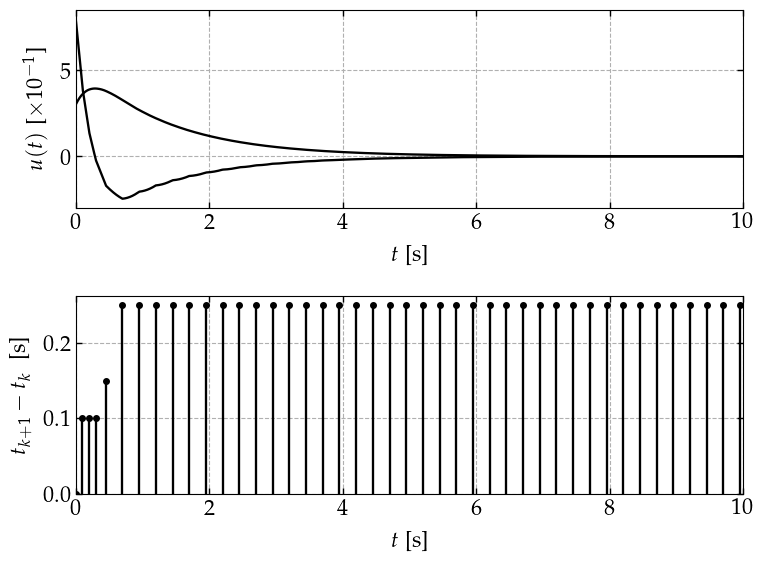

In [61]:
mosaic = [['y'], ['iet']]
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 6))

inter_event_times = nm.compute_deltas(events)
ks_iet = np.round(np.array(inter_event_times) / h).astype(int).tolist()

simulation_time = exp_data["duration"]
sampling_time = exp_data["design_params"]['h']
n_samples = simulation_time / sampling_time
saving = 100.0 * (1.0 - len(events) / (n_samples))
print("Média:", f"{(sum(inter_event_times) / len(inter_event_times)):.2f} s")
print("Economia:", f"{saving:.2f}%")

for i in range(plant.nu):
  gph.plot(
      axs['y'], t, y, xlabel='$t$', x_unit='s', x_use_prefixes=True,
      ylabel=r'$u(t)$', y_pad=(0.05, 0.05),
      cfg={**cfg, 'style': {'color': "black", "linestyle": ["-"], }},)

gph.stem(
    axs['iet'], events, inter_event_times,
    reuse_previous=False, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, t[-1]),
    ylabel='$t_{k+1} - t_k\\;$', y_unit='s', y_use_prefixes=True,
    cfg={**cfg, 'limits': {'x_min': 0, 'x_max': t[-1]}})

plt.tight_layout(pad=2.)

Sequência de Amostragem: [2, 2, 2, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]


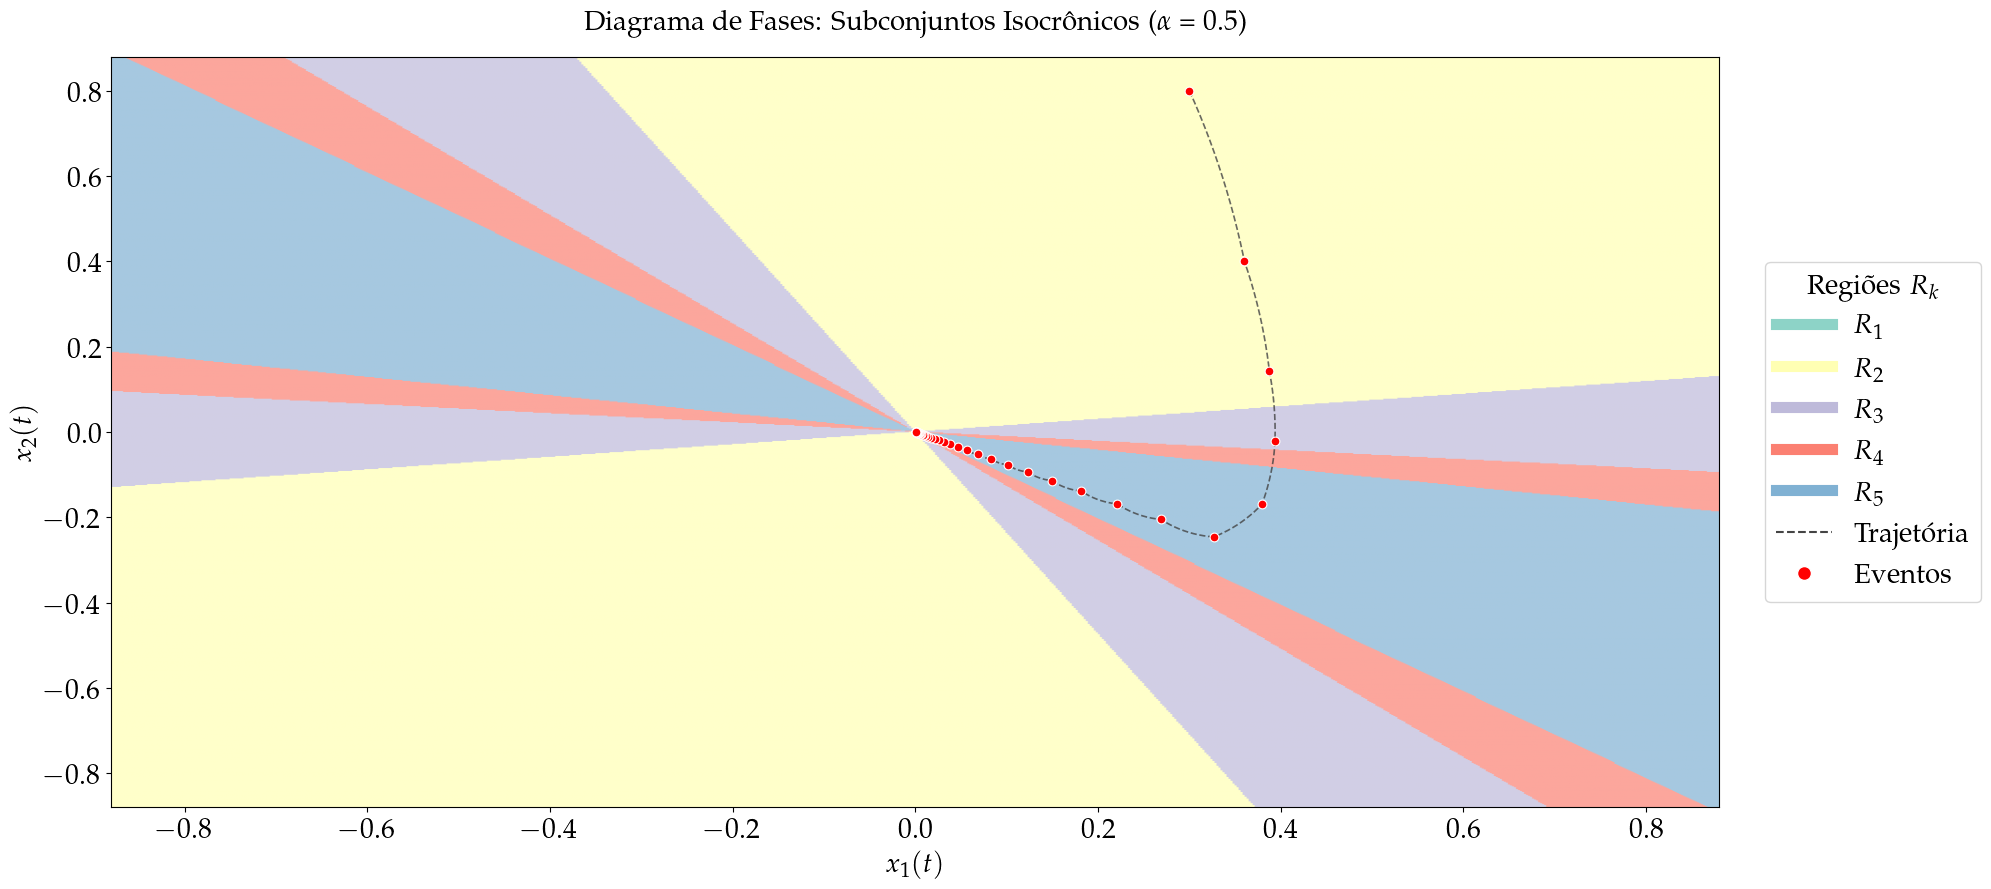

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

nu_bar = int(round(iet_max / h))
nx, nu = A.shape[0], B.shape[1]
I = np.eye(nx)


def get_Q_v(k):
  vk = k * h
  M_aux = np.zeros((nx + nu, nx + nu))
  M_aux[:nx, :nx], M_aux[:nx, nx:] = A, B
  Exp_aux = expm(M_aux * vk)
  Ad_v, Bd_v = Exp_aux[:nx, :nx], Exp_aux[:nx, nx:]
  A_cal_v = Ad_v + Bd_v @ K
  diff = I - A_cal_v
  return (A_cal_v.T @ Ψ @ A_cal_v) - (diff.T @ Ξ @ diff)


Q_cache = [get_Q_v(k) for k in range(1, nu_bar + 1)]

y_plot = y.T if y.shape[0] == nx else y
event_indices = [np.argmin(np.abs(t - e)) for e in events]
k_sequence = []

for idx in event_indices:
  x_ev = y_plot[idx].reshape(-1, 1)
  found = False
  for k_idx, Q in enumerate(Q_cache[:-1]):
    if x_ev.T @ Q @ x_ev < 0:
      k_sequence.append(k_idx + 1)
      found = True
      break
  if not found:
    k_sequence.append(nu_bar)

# seq_set_str = r"$\mathcal{S} = \{" + ", ".join(map(str, k_sequence)) + r"\}$"

limit = np.max(np.abs(y_plot)) * 1.1
res = 800
x_grid = np.linspace(-limit, limit, res)
X, Y = np.meshgrid(x_grid, x_grid)

Z = np.full(X.shape, nu_bar, dtype=int)
for k_val in range(nu_bar - 1, 0, -1):
  Q = Q_cache[k_val - 1]
  val = Q[0, 0]*X**2 + (Q[0, 1] + Q[1, 0])*X*Y + Q[1, 1]*Y**2
  Z[val < 0] = k_val

plt.figure(figsize=(20, 9), dpi=100)

base_cmap = plt.colormaps.get_cmap('Set3')
colors_list = [base_cmap(i / max(nu_bar, 12)) for i in range(nu_bar)]
custom_cmap = ListedColormap(colors_list)

im = plt.imshow(
    Z,
    extent=[-limit, limit, -limit, limit],
    origin='lower',
    cmap=custom_cmap,
    vmin=1,
    vmax=nu_bar,
    alpha=0.7,
    aspect='auto'
)

plt.plot(
    y_plot[:, 0], y_plot[:, 1],
    color='#444444',
    lw=1.2,
    ls='--',
    alpha=0.8,
    label=r'Trajetória $x(t)$'
)

plt.scatter(
    y_plot[event_indices, 0],
    y_plot[event_indices, 1],
    c='red',
    s=40,
    edgecolors='white',
    linewidth=0.8,
    zorder=10,
    label=r'Acionamentos'
)

plt.title(
    r'Diagrama de Fases: Subconjuntos Isocrônicos' +
    rf"  ($\alpha$ = {α:.1f})",
    fontsize=20,
    pad=20
)

plt.xlabel(r'$x_1(t)$', fontsize=20)
plt.ylabel(r'$x_2(t)$', fontsize=20)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

legend_elements = [
    Line2D([0], [0], color=colors_list[i], lw=8,
           label=f'$R_{{{i+1}}}$')
    for i in range(nu_bar)
]

plt.legend(
    handles=legend_elements + [
        Line2D([0], [0], color='#444444',
               lw=1.5, ls='--', label=r'Trajetória'),

        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='red',
               markersize=10,
               label=r'Eventos')
    ],
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    title=r"Regiões $R_k$",
    frameon=True,
    fontsize=20,
    title_fontsize=20
)

plt.tight_layout()

print(f"Sequência de Amostragem: {k_sequence}")

In [63]:
import numpy as np
import pandas as pd
from scipy.linalg import expm

# --- 1. Definição da Grade de Varredura ---
alphas = np.arange(0.1, 1.0, 0.05)       # Ex: 18 valores
upsilons = np.logspace(-3, -1, 10)         # 10 valores de 0.001 a 10.0
num_samples = 1500                       # Resolução angular
angles = np.linspace(0, 2 * np.pi, num_samples)

all_results = []
nx, nu = A.shape[0], B.shape[1]
I = np.eye(nx)

print(f"Iniciando Varredura 2D: {len(alphas) * len(upsilons)} combinações...")

# --- 2. Loop Bidimensional ---
for u_val in upsilons:
  for a_val in alphas:
    # Síntese via LMI
    result = run_problem_solving(h=h, υ=u_val, α=a_val)

    if not result or result['status'] != 'optimal':
      continue

    Xi_now, Psi_now = result['etm']['Ξ'], result['etm']['Ψ']
    K_now = result['controller']['K']

    # Pré-cálculo das Matrizes Q_k
    Q_cache = []
    for k in range(1, nu_bar + 1):
      vk = k * h
      M_aux = np.zeros((nx + nu, nx + nu))
      M_aux[:nx, :nx], M_aux[:nx, nx:] = A, B
      Exp_aux = expm(M_aux * vk)
      A_cal_v = Exp_aux[:nx, :nx] + Exp_aux[:nx, nx:] @ K_now
      diff = I - A_cal_v
      Q_k = (A_cal_v.T @ Psi_now @ A_cal_v) - (diff.T @ Xi_now @ diff)
      Q_cache.append(Q_k)

    # Cálculo dos Volumes
    counts = np.zeros(nu_bar)
    for theta in angles:
      x = np.array([[np.cos(theta)], [np.sin(theta)]])
      ist_found = nu_bar
      for k_idx in range(nu_bar - 1):
        if x.T @ Q_cache[k_idx] @ x < 0:
          ist_found = k_idx + 1
          break
      counts[ist_found - 1] += 1

    # Armazenamento (Sem prints para velocidade)
    for k in range(1, nu_bar + 1):
      qty = counts[k-1]
      if qty > 0:
        all_results.append({
            'alpha': a_val,
            'upsilon': u_val,
            'region': f'R_{k}',
            'percentage': (qty / num_samples) * 100
        })

# Salvar arquivo
df_2d = pd.DataFrame(all_results)
df_2d.to_csv('df_volumes_2d_full.csv', index=False, encoding='utf-8')
print("Varredura concluída. Dados salvos em 'df_volumes_2d_full.csv'.")

Iniciando Varredura 2D: 180 combinações...
Varredura concluída. Dados salvos em 'df_volumes_2d_full.csv'.


Gerando gráficos com eixos independentes...


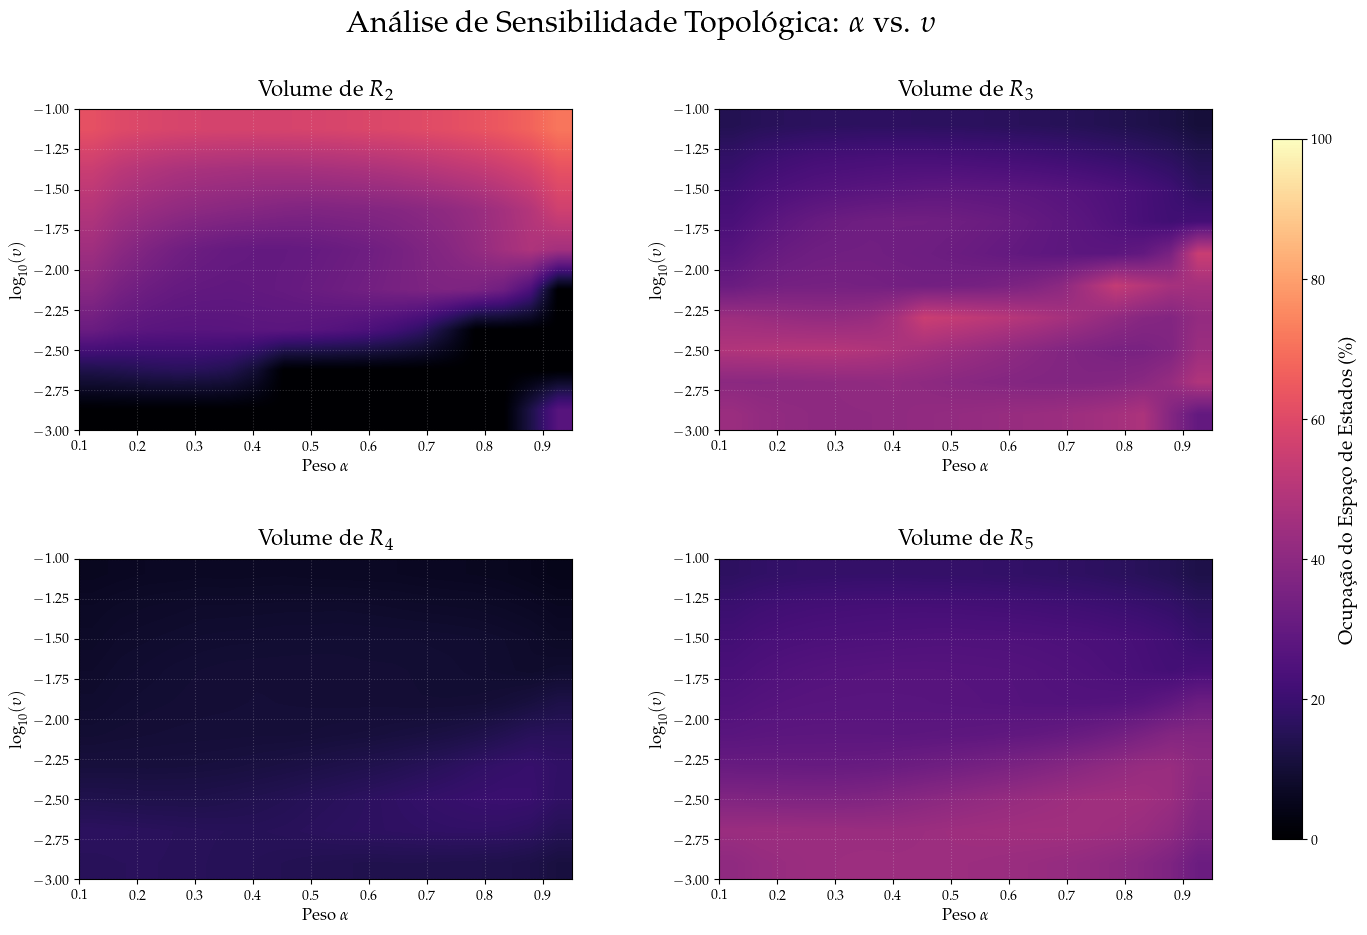

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar dados
df = pd.read_csv('df_volumes_2d_full.csv')

# Obter lista única de regiões e parâmetros
regioes = sorted(df['region'].unique(), key=lambda x: int(x.split('_')[1]))
n_regioes = len(regioes)
alphas = sorted(df['alpha'].unique())
upsilons = sorted(df['upsilon'].unique())

# 2. Configurar a grade de subplots (2 colunas para melhor visibilidade)
cols = 2
rows = (n_regioes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()

cmap_style = "magma"

print("Gerando gráficos com eixos independentes...")

for i, r_name in enumerate(regioes):
  ax = axes[i]

  # Filtrar e pivotar
  df_r = df[df['region'] == r_name]
  pivot = df_r.pivot(index='upsilon', columns='alpha',
                     values='percentage').fillna(0)

  # Plotagem com imshow (interpolação suave)
  im = ax.imshow(pivot.values,
                 extent=[min(alphas), max(alphas), np.log10(
                     min(upsilons)), np.log10(max(upsilons))],
                 aspect='auto', origin='lower', cmap=cmap_style, interpolation='bilinear',
                 vmin=0, vmax=100)

  # Título limpo em LaTeX (removido parênteses extras)
  ax.set_title(rf'Volume de ${r_name}$', fontsize=16, pad=10)

  # Forçar exibição de eixos em cada figura
  ax.set_xlabel(r'Peso $\alpha$', fontsize=12)
  ax.set_ylabel(r'$\log_{10}(\upsilon)$', fontsize=12)

  # Adicionar grid discreto para referência
  ax.grid(True, linestyle=':', alpha=0.2, color='white')

# 3. Limpeza de subplots vazios
for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

# 4. Ajustes Finais e Barra de Cores Global
plt.suptitle(r'Análise de Sensibilidade Topológica: $\alpha$ vs. $\upsilon$',
             fontsize=22)

# Adiciona a barra de cores à direita
fig.subplots_adjust(right=0.88, hspace=0.4, wspace=0.3)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'Ocupação do Espaço de Estados (\%)', fontsize=14)

# plt.tight_layout()

In [65]:
%%skip

import numpy as np
from scipy.linalg import expm


def get_analytical_volumes(Xi, Psi, K, h, nu_bar, plant_A, plant_B):
  """
  Calcula as porcentagens de área de cada região R_k analiticamente para nx=2.
  Baseado na subtração de intervalos angulares.
  """
  nx, nu = plant_A.shape[0], plant_B.shape[1]
  I = np.eye(nx)

  res_ang = 10000
  thetas = np.linspace(0, np.pi, res_ang)
  x_circle = np.array([np.cos(thetas), np.sin(thetas)])

  disparo_mask = np.zeros((nu_bar, res_ang), dtype=bool)

  for k in range(1, nu_bar + 1):
    vk = k * h
    M_aux = np.zeros((nx + nu, nx + nu))
    M_aux[:nx, :nx], M_aux[:nx, nx:] = plant_A, plant_B
    Exp = expm(M_aux * vk)
    A_cal = Exp[:nx, :nx] + Exp[:nx, nx:] @ K

    diff = I - A_cal
    Q_k = (A_cal.T @ Psi @ A_cal) - (diff.T @ Xi @ diff)

    val = Q_k[0, 0]*x_circle[0]**2 + \
        (Q_k[0, 1]+Q_k[1, 0])*x_circle[0] * \
        x_circle[1] + Q_k[1, 1]*x_circle[1]**2
    disparo_mask[k-1] = (val < 0)

  r_k_volumes = np.zeros(nu_bar)
  ja_disparou = np.zeros(res_ang, dtype=bool)

  for k in range(nu_bar):
    atualmente_em_rk = disparo_mask[k] & ~ja_disparou
    r_k_volumes[k] = np.sum(atualmente_em_rk)
    ja_disparou |= disparo_mask[k]

  total = np.sum(r_k_volumes)
  percentages = (r_k_volumes / total) * 100

  p = percentages[percentages > 0] / 100.0
  entropy = -np.sum(p * np.log2(p))

  return percentages, entropy


h = exp_data["design_params"]['h']
iet_max = exp_data["design_params"]['iet_max']
nu_bar = int(round(iet_max / h))
res = run_problem_solving(h=h, υ=1e-1, α=0.5)
if res:
  plant_matrices = plant.evaluate_matrices(None, None, None)
  vols, H = get_analytical_volumes(res['etm']['Ξ'], res['etm']['Ψ'],
                                   res['controller']['K'], h, nu_bar,
                                   plant_matrices['A'], plant_matrices['B'])

  print(f"Entropia de Shannon: {H:.4f}")
  for i, v in enumerate(vols):
    if v > 0:
      print(f"R_{i+1}: {v:.2f}%")
else:
  print("!!! O problema restou Inviável para estes parâmetros !!!")

Cell skipped (unconditional).


In [66]:
%%skip
import numpy as np
from scipy.optimize import differential_evolution


def obj_func_shannon(params):
  alpha_val, log_upsilon = params
  upsilon_val = 10**log_upsilon

  result = run_problem_solving(h=h, υ=upsilon_val, α=alpha_val)
  if result is None:
    return 10.0

  nu_bar = 10
  plant_matrices = plant.evaluate_matrices(None, None, None)
  _, shannon_entropy = get_analytical_volumes(
      result['etm']['Ξ'], result['etm']['Ψ'],
      result['controller']['K'], h, nu_bar,
      plant_matrices['A'], plant_matrices['B']
  )

  return -shannon_entropy


bounds = [(0.1, 0.99), (-4, 1)]  # [Alpha, Log10(Upsilon)]

print("Iniciando Otimização da Entropia de Shannon")
res_opt = differential_evolution(obj_func_shannon, bounds, strategy='best1bin',
                                 popsize=10, tol=1e-3, mutation=(0.5, 1))

if res_opt.success:
  best_a, best_log_u = res_opt.x
  print("\n" + "="*40)
  print("   RESULTADOS DA OTIMIZAÇÃO   ")
  print("="*40)
  print(f"ENTROPIA: {-res_opt.fun:.4f}")
  print(f"ALPHA:    {best_a:.4f}")
  print(f"UPSILON:  {10**best_log_u:.4e}")
  print("="*40)

Cell skipped (unconditional).


In [67]:
%%skip

import numpy as np
import pandas as pd

n_alpha = 25
n_upsilon = 100

alphas = np.linspace(0.1, 0.99, n_alpha)
upsilons = np.logspace(-4, 1, n_upsilon)

best_entropy = -1.0
best_params = {'alpha': None, 'upsilon': None, 'vols': None}
results_log = []  # Para análise posterior se necessário

print(f"Iniciando Busca em Grade: {n_alpha * n_upsilon} combinações...")

for u_val in upsilons:
  for a_val in alphas:
    result = run_problem_solving(h=h, υ=u_val, α=a_val)

    if result and result['status'] == 'optimal':
      plant_matrices = plant.evaluate_matrices(None, None, None)
      vols, entropy = get_analytical_volumes(
          result['etm']['Ξ'], result['etm']['Ψ'],
          result['controller']['K'], h, nu_bar,
          plant_matrices['A'], plant_matrices['B']
      )

      if entropy > best_entropy:
        best_entropy = entropy
        best_params = {
            'alpha': a_val,
            'upsilon': u_val,
            'vols': vols
        }

      results_log.append(
          {'alpha': a_val, 'upsilon': u_val, 'entropy': entropy})

print("\n" + "="*40)
print("       RESULTADO DA BUSCA EM GRADE")
print("="*40)
if best_params['alpha'] is not None:
  print(f"MAIOR ENTROPIA ENCONTRADA: {best_entropy:.4f}")
  print(f"MELHOR ALPHA:   {best_params['alpha']:.4f}")
  print(f"MELHOR UPSILON: {best_params['upsilon']:.4e}")
  print("-" * 40)
  print("Distribuição de Volumes no Ponto Ótimo:")
  for k, v in enumerate(best_params['vols']):
    if v > 0.01: 
      print(f"  R_{k+1}: {v:.2f}%")
else:
  print("Nenhum ponto viável foi encontrado na grade.")
print("="*40)

df_grid = pd.DataFrame(results_log)

Cell skipped (unconditional).


In [68]:
def get_cone_center_2d(Q):
  eigvals, eigvecs = np.linalg.eigh(Q)
  return eigvecs[:, np.argmin(eigvals)]

In [69]:
%%skip

from scipy.optimize import differential_evolution
import numpy as np
from scipy.linalg import expm, norm


def discretize_closed_loop(A, B, K, vk):
  """Discretização exata ZOH para malha fechada."""
  nx, nu = A.shape[0], B.shape[1]
  M = np.zeros((nx + nu, nx + nu))
  M[:nx, :nx], M[:nx, nx:] = A, B
  ExpM = expm(M * vk)
  return ExpM[:nx, :nx] + ExpM[:nx, nx:] @ K


def get_jump_angle(Phi_cl, x):
  """Calcula o ângulo de deflexão entre o estado atual e o próximo."""
  x_next = Phi_cl @ x
  cos_theta = np.dot(x, x_next) / (norm(x) * norm(x_next) + 1e-12)
  angle = np.arccos(np.clip(cos_theta, -1.0, 1.0))
  return angle


def objective_angular_divergence(params):
  alpha_val, log_upsilon = params
  u_val = 10**log_upsilon

  res = run_problem_solving(h=h, υ=u_val, α=alpha_val)
  if res is None:
    return 100.0

  K = res['controller']['K']
  plant_eval = plant.evaluate_matrices(None, None, None)
  A_p, B_p = plant_eval['A'], plant_eval['B']

  total_torsion = 0
  thetas = np.linspace(0, 2*np.pi, 12, endpoint=False)
  directions = np.array([np.cos(thetas), np.sin(thetas)]).T  # (12, 2)

  test_ks = [1, 5, 10]

  for k_test in test_ks:
    vk = k_test * h
    Phi_cl = discretize_closed_loop(A_p, B_p, K, vk)

    for x in directions:
      angle = get_jump_angle(Phi_cl, x)
      total_torsion += angle

  return -total_torsion


print("Iniciando Otimização por Divergência Angular (Torsão Dinâmica)...")

res_de = differential_evolution(
    objective_angular_divergence,
    bounds=[(0.1, 0.99), (-4, 0)],
    strategy='best1bin',
    popsize=20,
    seed=42,
    polish=True,
    workers=1
)

if res_de.success:
  best_a, best_u = res_de.x[0], 10**res_de.x[1]
  print("\n" + "="*45)
  print("      PROJETO VIA DIVERGÊNCIA ANGULAR")
  print("="*45)
  print(f"Alpha:   {best_a:.6f}")
  print(f"Upsilon: {best_u:.6e}")
  print(f"Torsão Acumulada (Score): {-res_de.fun:.4f}")
  print("="*45)

Cell skipped (unconditional).


### Cálculo da Entropia Topológica

In [70]:
import networkx as nx
import numpy as np
import scipy.sparse.linalg as sla
from scipy import linalg as la


def calculate_spectral_radius_entropy(G):
  """Lógica central para cálculo de raio espectral e log2."""
  if G.number_of_nodes() == 0:
    return 0.0

  # Conversão para matriz de adjacência
  adj_matrix = nx.adjacency_matrix(G).astype(float)

  try:
    # Solver Adaptativo (Sparse vs Dense)
    if G.number_of_nodes() < 500:
      vals = la.eigvals(adj_matrix.toarray())
      rho = float(np.max(np.abs(vals)))
    else:
      vals = sla.eigs(adj_matrix, k=1, which='LM',
                      return_eigenvectors=False)
      rho = float(np.abs(vals[0]))

    # Limiar de Caos (1e-9) conforme CBA
    return float(np.log2(rho)) if rho > (1.0 + 1e-9) else 0.0
  except:
    return 0.0


def get_recurrent_entropy(G_complete):
  """
  Calcula a entropia topológica considerando apenas os ciclos (SCCs).
  Representa a complexidade no regime permanente (Steady-state).
  """
  if G_complete.number_of_nodes() == 0:
    return 0.0

  # Identificação de Nós Recorrentes (Somente Ciclos e SCCs)
  sccs = list(nx.strongly_connected_components(G_complete))
  recurrent_nodes = set()
  for scc in sccs:
    # Um componente só gera entropia se for um ciclo (>1 nó ou self-loop)
    if len(scc) > 1 or (len(scc) == 1 and G_complete.has_edge(list(scc)[0], list(scc)[0])):
      recurrent_nodes.update(scc)

  if not recurrent_nodes:
    return 0.0

  # Extração do subgrafo e cálculo
  Gr = G_complete.subgraph(recurrent_nodes)
  return calculate_spectral_radius_entropy(Gr)

In [ ]:
import scipy.linalg as la
import networkx as ntx


h = exp_data["design_params"]['h']
iet_max = 5 * h
# iet_max = exp_data["design_params"]['iet_max']
K_set = [i + 1 for i in range(int(round(iet_max / h)))]

A = plant.evaluate_matrices(None, None, None)['A']
B = plant.evaluate_matrices(None, None, None)['B']
nu_bar = int(round(iet_max / h))

print("h:", h)
print("iet_max:", iet_max)

υ = 1e-2
α = 0.1
# result = run_problem_solving(h=h, υ=υ, α=α)
result = solve_problem_sigma(h=h, υ=υ, σ=.9)

Ξ = result['etm']['Ξ']
Ψ = result['etm']['Ψ']
K = result['controller']['K']


L_WORD = 28
builder = tm.TrafficModelBuilder(
    A=A, B=B, K=K,
    Xi=Ξ, Psi=Ψ,
    h=h, nu_bar_time=iet_max
)

G_complete = builder.build_exact_l_complete_graph(
    ell=L_WORD,
    K_set=K_set,
    max_workers=None,
    verbose=True
)

# G_complete = build_symbolic_exactly_graph(
#     target_l=L_WORD, K_set=K_set, h=h, A=A,
#     B=B, K=K, Xi=Ξ, Psi=Ψ, iet_max=iet_max
# )

print(
    f"\nGrafo gerado com {G_complete.number_of_nodes()} nós e {G_complete.number_of_edges()} arestas.")


behavioral_entropy = get_recurrent_entropy(G_complete)

print(f"Entropia Comportamental (Topológica): {behavioral_entropy:.4f} bits")

h: 0.05
iet_max: 0.25
=== [Init] Calculando Filtro Topológico (Main Process) ===
   Transições base mapeadas: 14
=== [Multiprocessing] Distribuindo galhos para \ell=28 ===


In [72]:
import numpy as np
import networkx as ntx
from scipy import linalg as la


def get_all_lower_l_models_and_entropy(G_max, L_max):
  """
  Obtém modelos l-completos e suas entropias para todos os valores 
  abaixo de L_max usando apenas manipulação de conjuntos (Custo Zero).
  """
  results = {}

  results[L_max] = {
      'nodes': G_max.number_of_nodes(),
      'edges': G_max.number_of_edges(),
      'entropy': get_recurrent_entropy(G_max)
  }

  current_nodes = set(G_max.nodes())
  for ell in range(L_max - 1, 0, -1):
    new_edges = [(seq[:-1], seq[1:]) for seq in current_nodes]
    new_nodes = set()

    for u, v in new_edges:
      new_nodes.add(u)
      new_nodes.add(v)

    G_ell = ntx.DiGraph()
    G_ell.add_nodes_from(new_nodes)
    G_ell.add_edges_from(new_edges)

    results[ell] = {
        'nodes': G_ell.number_of_nodes(),
        'edges': G_ell.number_of_edges(),
        'entropy': get_recurrent_entropy(G_ell)
    }

    current_nodes = new_nodes

  return results

In [73]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_entropy(
    stats_dict: dict,
    x_label: str = r'$\ell$',
    log_x: bool = False
) -> None:
  """
  Plota a entropia vs l diretamente a partir do dicionário 'stats',
  sem necessidade de DataFrames ou dicionários auxiliares de filtragem.
  """
  # 1. Extração direta dos dados (Ordenando por l para garantir a curva correta)
  ells = sorted(stats_dict.keys())
  entropies = [stats_dict[l]['entropy'] for l in ells]

  if not ells:
    print("Aviso: Variável stats está vazia.")
    return

  # 2. Configuração do Plot
  fig, ax = plt.subplots(figsize=(8, 4))

  ax.plot(ells, entropies, marker='s', color='black',
          linestyle='--', linewidth=2, label=fr'$\bar{{\nu}} = {len(ells)}$')

  ax.set_xlabel(x_label, fontsize=16)
  ax.set_ylabel(
      r'$\mathcal{H}_b(\mathcal{T}_{\ell})$ [bits]', color='black', fontsize=16)
  ax.tick_params(axis='both', labelsize=16)

  # 3. Formatação dos Eixos
  if log_x:
    ax.set_xscale('log')
  else:
    ax.set_xticks(ells)
    ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:g}'))

  ax.set_xlim(min(ells) - 0.25, max(ells) + 0.25)
  ax.set_title(rf'Convergence of Behavioral Entropy', fontsize=14)
  ax.legend(loc='best', framealpha=0.95, fontsize=13)
  ax.grid(True, linestyle='--', alpha=0.87)

  plt.tight_layout()
  plt.show()

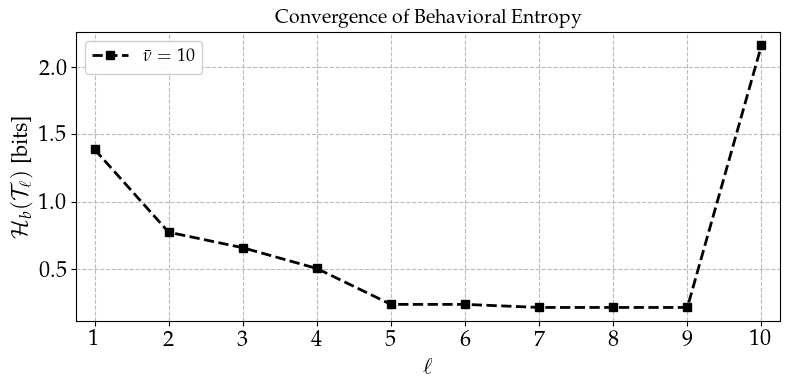

In [74]:
# %%skip
stats = get_all_lower_l_models_and_entropy(G_complete, L_WORD)
plot_entropy(stats)

In [75]:
model_builder = tm.IsochronousPartitionModel(
    A=A, B=B, K=K, Xi=Ξ, Psi=Ψ, h=h, nu_bar_time=iet_max
)
G_steady = model_builder.build_partition_graph()

try:
  # Se sua função espera o grafo:
  h_top = get_recurrent_entropy(G_steady)

  print(f"\n--- Resultado Final ---")
  print(f"Entropia em Regime Permanente: {h_top:.4f} bits")
  print(f"Nós no modelo reduzido: {G_steady.number_of_nodes()}")
  print(f"Arestas no modelo reduzido: {G_steady.number_of_edges()}")

except NameError:
  print("\n[Erro] Função de entropia não encontrada. Use sua implementação aqui.")

Verificando transições entre 5 regiões isócronas...

--- Resultado Final ---
Entropia em Regime Permanente: 1.3885 bits
Nós no modelo reduzido: 5
Arestas no modelo reduzido: 8
